[1/7] Membaca database Multi-Fasies...
Kelas terdeteksi: ['Coal' 'Dolomite' 'Limestone' 'Sandstone' 'Shale' 'Shaly Sand']

[2/7] Membuat Sequence Windows (Konteks Spasial)...

[3/7] Membangun Arsitektur Bidirectional LSTM (6 Output)...



[4/7] Memulai Pelatihan Model...
Epoch 1/25


247/247 [==============================] - 19s 46ms/step - loss: 0.2594 - accuracy: 0.8836 - val_loss: 0.4849 - val_accuracy: 0.7721 - lr: 0.0010
Epoch 2/25
247/247 [==============================] - 9s 38ms/step - loss: 0.1591 - accuracy: 0.9166 - val_loss: 0.5996 - val_accuracy: 0.7971 - lr: 0.0010
Epoch 3/25
247/247 [==============================] - 9s 38ms/step - loss: 0.1412 - accuracy: 0.9266 - val_loss: 0.4872 - val_accuracy: 0.8359 - lr: 0.0010
Epoch 4/25
247/247 [==============================] - 9s 38ms/step - loss: 0.1276 - accuracy: 0.9347 - val_loss: 0.4453 - val_accuracy: 0.8729 - lr: 5.0000e-04
Epoch 5/25
247/247 [==============================] - 10s 41ms/step - loss: 0.1191 - accuracy: 0.

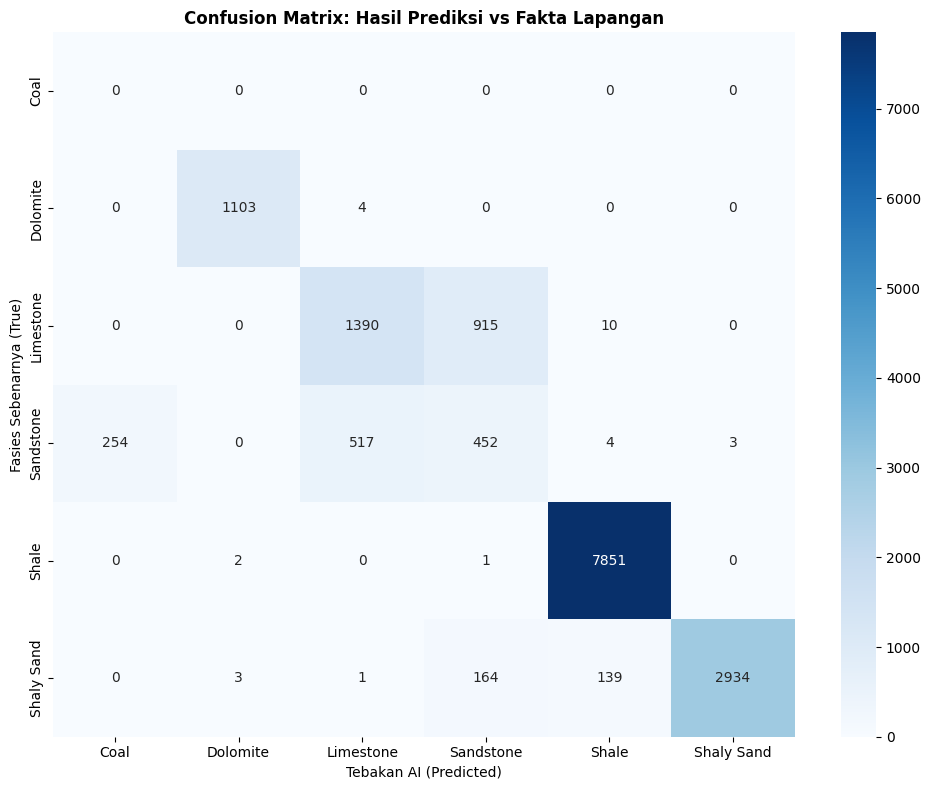


[6/7] Membangun Visualisasi Log Plot Komparatif...
2461/2461 [==============================] - 11s 5ms/step


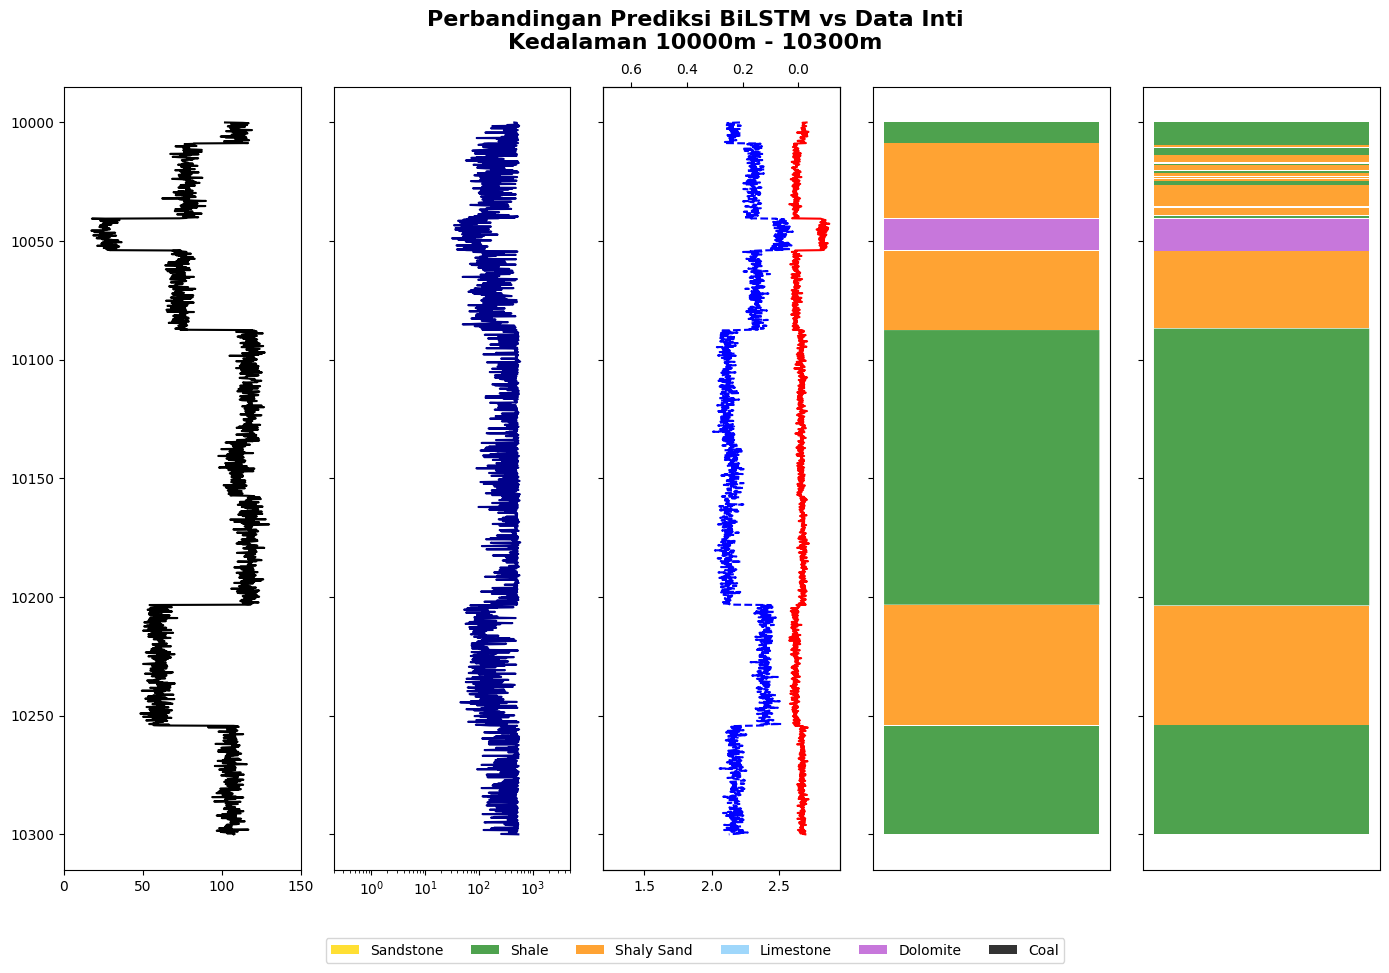


[7/7] Menyimpan Model dan Tools Preprocessing untuk Deployment...
✅ SUKSES! File 'model_bilstm_fasies.h5', 'scaler_fasies.pkl', dan 'encoder_fasies.pkl' telah dibuat.
   Sekarang Anda bisa menjalankan skrip Deployment pembaca file LAS.


C:\Users\kunde\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # DITAMBAHKAN: Untuk menyimpan scaler dan encoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. MEMBACA DATA & PREPROCESSING
# ==========================================
print("[1/7] Membaca database Multi-Fasies...")
try:
    df = pd.read_excel("MultiFacies_Petrofisika.xlsx", sheet_name="Well_Logs")
except FileNotFoundError:
    print("Error: File 'MultiFacies_Petrofisika.xlsx' tidak ditemukan. Jalankan skrip pembuat data terlebih dahulu.")
    exit()

fitur = ['GR', 'RHOB', 'NPHI', 'RT']
X_raw = df[fitur].values
y_raw = df['True_Facies'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_raw)
y_categorical = to_categorical(y_encoded)

kelas_fasies = encoder.classes_
print(f"Kelas terdeteksi: {kelas_fasies}")

# ==========================================
# 2. SEQUENCE WINDOWING UNTUK LSTM
# ==========================================
print("\n[2/7] Membuat Sequence Windows (Konteks Spasial)...")
window_size = 11  
half_window = window_size // 2

def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(half_window, len(X) - half_window):
        X_seq.append(X[i - half_window : i + half_window + 1])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_categorical, window_size)

split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# ==========================================
# 3. MEMBANGUN ARSITEKTUR BiLSTM
# ==========================================
print("\n[3/7] Membangun Arsitektur Bidirectional LSTM (6 Output)...")
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(window_size, len(fitur))),
    BatchNormalization(),
    Dropout(0.3),
    
    Bidirectional(LSTM(32)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dense(len(kelas_fasies), activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 4. PELATIHAN MODEL (TRAINING)
# ==========================================
print("\n[4/7] Memulai Pelatihan Model...")
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 5. EVALUASI STATISTIK
# ==========================================
print("\n[5/7] Evaluasi Statistik pada Data Uji (Unseen Data)...")
y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

y_pred_labels = encoder.inverse_transform(y_pred_classes)
y_true_labels = encoder.inverse_transform(y_true_classes)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true_labels, y_pred_labels, labels=kelas_fasies, target_names=kelas_fasies, zero_division=0))

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=kelas_fasies)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=kelas_fasies, yticklabels=kelas_fasies)
plt.title('Confusion Matrix: Hasil Prediksi vs Fakta Lapangan', fontweight='bold')
plt.ylabel('Fasies Sebenarnya (True)')
plt.xlabel('Tebakan AI (Predicted)')
plt.tight_layout()
plt.show()

# ==========================================
# 6. VISUALISASI LOG SUMUR 
# ==========================================
print("\n[6/7] Membangun Visualisasi Log Plot Komparatif...")
all_predictions = model.predict(X_seq)
all_predicted_classes = np.argmax(all_predictions, axis=1)

df_result = df.iloc[half_window : -half_window].copy()
df_result['Predicted_Facies'] = encoder.inverse_transform(all_predicted_classes)

def plot_multifacies_results(df_res, start_depth=10000, end_depth=10300):
    plot_df = df_res[(df_res['Depth'] >= start_depth) & (df_res['Depth'] <= end_depth)]
    if plot_df.empty: return

    fig, axes = plt.subplots(figsize=(14, 10), ncols=5, sharey=True)
    fig.suptitle(f'Perbandingan Prediksi BiLSTM vs Data Inti\nKedalaman {start_depth}m - {end_depth}m', fontsize=16, fontweight='bold', y=0.98)

    axes[0].plot(plot_df['GR'], plot_df['Depth'], color='black')
    axes[0].set_xlim(0, 150)
    axes[0].invert_yaxis()
    
    axes[1].plot(plot_df['RT'], plot_df['Depth'], color='darkblue')
    axes[1].set_xscale('log')
    axes[1].set_xlim(0.2, 5000)
    
    ax2 = axes[2]
    ax2.plot(plot_df['RHOB'], plot_df['Depth'], color='red')
    ax2.set_xlim(1.2, 2.95) 
    
    ax2_twin = ax2.twiny()
    ax2_twin.plot(plot_df['NPHI'], plot_df['Depth'], color='blue', linestyle='--')
    ax2_twin.set_xlim(0.7, -0.15) 

    color_map = {'Sandstone': 'gold', 'Shale': 'forestgreen', 'Shaly Sand': 'darkorange',
                 'Limestone': 'lightskyblue', 'Dolomite': 'mediumorchid', 'Coal': 'black'}

    ax3 = axes[3]
    for fasies, color in color_map.items():
        ax3.fill_betweenx(plot_df['Depth'], 0, 1, where=(plot_df['True_Facies'] == fasies), facecolor=color, alpha=0.8, label=fasies)
    ax3.set_xticks([])
    
    ax4 = axes[4]
    for fasies, color in color_map.items():
        ax4.fill_betweenx(plot_df['Depth'], 0, 1, where=(plot_df['Predicted_Facies'] == fasies), facecolor=color, alpha=0.8)
    ax4.set_xticks([])
    
    handles, labels = ax3.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.02), fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12) 
    plt.show()

plot_multifacies_results(df_result, start_depth=10000, end_depth=10300)

# ==========================================
# 7. MENYIMPAN MODEL & PREPROCESSING TOOLS (EXPORT)
# ==========================================
print("\n[7/7] Menyimpan Model dan Tools Preprocessing untuk Deployment...")

# Simpan arsitektur dan bobot model Keras
model.save("model_bilstm_fasies.h5")

# Simpan Scaler (agar skala angka data LAS baru seragam dengan data training)
joblib.dump(scaler, "scaler_fasies.pkl")

# Simpan Encoder (agar mapping angka kembali ke teks fasies konsisten)
joblib.dump(encoder, "encoder_fasies.pkl")

print("✅ SUKSES! File 'model_bilstm_fasies.h5', 'scaler_fasies.pkl', dan 'encoder_fasies.pkl' telah dibuat.")
print("   Sekarang Anda bisa menjalankan skrip Deployment pembaca file LAS.")